# RQ1 - Clones (LLMs, no LLM era, Agentic)

## Creating/loading parquet file for faster access

In [ ]:
from pathlib import Path
import pandas as pd
import ijson

RESULTS_DIR = Path("../../results")
PARQUET_FILE = RESULTS_DIR / "results.parquet"

if PARQUET_FILE.exists():
    print(f"Loading existing {PARQUET_FILE.name}...")
    df = pd.read_parquet(PARQUET_FILE)

else:
    print("First create Parquet file with create_parquet.py")

 
print(df.shape)
print(df["generation_type"].value_counts())
print(df.head())

Creating Parquet file...
Found 102 JSON files
Processing 0000_codespecs_daikon_05f3ce2b80a0_detailed_results.json (index=0, type=no_llm, project=codespecs_daikon_05f3ce2b80a0)
  → 239540 rows
Processing 0001_codespecs_daikon_9248a320cff0_detailed_results.json (index=1, type=agentic, project=codespecs_daikon_9248a320cff0)
  → 241862 rows
Processing 0002_talsma-ict_umldoclet_7d9c23724747_detailed_results.json (index=2, type=no_llm, project=talsma-ict_umldoclet_7d9c23724747)
  → 471064 rows
Processing 0003_talsma-ict_umldoclet_a45be18a2f81_detailed_results.json (index=3, type=agentic, project=talsma-ict_umldoclet_a45be18a2f81)
  → 20356 rows
Processing 0004_hazendaz_displaytag_a48cd64d7466_detailed_results.json (index=4, type=no_llm, project=hazendaz_displaytag_a48cd64d7466)
  → 42638 rows
Processing 0005_hazendaz_displaytag_45fef5f8b4bf_detailed_results.json (index=5, type=agentic, project=hazendaz_displaytag_45fef5f8b4bf)
  → 40716 rows
Processing 0006_cryptomator_cryptofs_0def3661ef8c_

## Compare distributions

In [ ]:
df.groupby("generation_type")[["sim", "codebleu"]].mean()

,sim,codebleu
agentic,,
False,0.575282,0.41902
True,0.627048,0.501535


## Boxplots

In [ ]:
from pathlib import Path
import pandas as pd

# Keep only what is needed for the plots
plot_df = df[
    ["language", "generation_type", "sim", "codebleu", "model"]
].copy()

# Convert once
plot_df["sim"] = pd.to_numeric(plot_df["sim"], errors="coerce")
plot_df["codebleu"] = pd.to_numeric(plot_df["codebleu"], errors="coerce")

# Remove rows that cannot be plotted
plot_df = plot_df.dropna(
    subset=["language", "generation_type"]
)

# Optional: enforce a consistent order
plot_df["generation_type"] = pd.Categorical(
    plot_df["generation_type"],
    categories=["no_llm", "llm", "agentic"],
    ordered=True
)

# Save the prepared data
Path("plots").mkdir(exist_ok=True)

plot_df.to_csv(
    "plots/similarity_comparison_data.csv",
    index=False
)

### Semantic/Syntactic similarity

,Language,Metric,Model,Version,N,Mean,Median,Std,Min,Q1,Q3,Max
0,Java,Cosine Similarity,CodeBERT-Cosine Sim.,Non-Agentic,4847651,0.5879,0.6290,0.3266,-0.2611,0.2963,0.9008,1.0000
1,Java,Cosine Similarity,CodeBERT-Cosine Sim.,Agentic,6316352,0.5969,0.6352,0.3200,-0.2141,0.3166,0.9045,1.0000
2,Java,Cosine Similarity,CodeT5-Cosine Sim.,Non-Agentic,4847651,0.7018,0.7644,0.2608,-0.2176,0.5166,0.9297,1.0000
3,Java,Cosine Similarity,CodeT5-Cosine Sim.,Agentic,6316352,0.7067,0.7671,0.2557,-0.2107,0.5277,0.9293,1.0000
4,Java,CodeBLEU,N/A,Non-Agentic,9695302,0.5148,0.5029,0.2985,0.0000,0.2189,0.7443,1.0000
5,Java,CodeBLEU,N/A,Agentic,12632704,0.5372,0.5520,0.2886,0.0000,0.2725,0.7564,1.0000
6,Python,Cosine Similarity,CodeBERT-Cosine Sim.,Non-Agentic,2612679,0.3941,0.2870,0.3359,-0.2243,0.1114,0.6655,1.0000
7,Python,Cosine Similarity,CodeBERT-Cosine Sim.,Agentic,1450163,0.4766,0.3820,0.3719,-0.2034,0.1337,0.9123,1.0000
8,Python,Cosine Similarity,CodeT5-Cosine Sim.,Non-Agentic,2612679,0.4983,0.4770,0.3084,-0.2167,0.2292,0.7690,1.0000
9,Python,Cosine Similarity,CodeT5-Cosine Sim.,Agentic,1450163,0.5617,0.5762,0.3227,-0.2219,0.2740,0.8717,1.0000


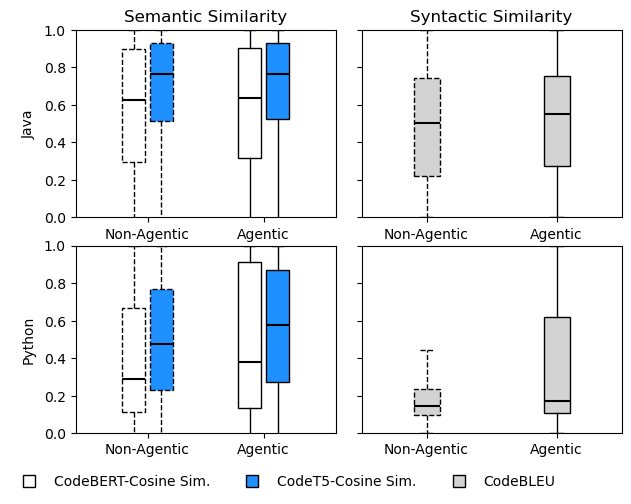

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path


plot_df = pd.read_csv("plots/similarity_comparison_data.csv")

model_names = {
    "microsoft/codebert-base-ft": "CodeBERT-Cosine Sim.",
    "Salesforce/codet5-base-ft": "CodeT5-Cosine Sim."
}

languages = plot_df["language"].unique()
models = plot_df["model"].dropna().unique()

# Consistent order for the three conditions
generation_types = [
    "no_llm",
    "llm",
    "agentic"
]

generation_labels = {
    "no_llm": "No LLM",
    "llm": "LLM",
    "agentic": "Agentic"
}

# Colors for the different models (cosine similarity only)
model_colors = {
    models[0]: "white",
    models[1]: "dodgerblue",
}

# Color for CodeBLEU
codebleu_color = "lightgray"


fig, axes = plt.subplots(
    len(languages),
    2,
    figsize=(7, 2.4 * len(languages)),
    squeeze=False
)


# ============================================================
# Textual summary
# ============================================================

summary = []

for language in languages:

    lang_df = plot_df[plot_df["language"] == language]

    # --------------------------------------------------------
    # Cosine similarity: one entry per model and generation type
    # --------------------------------------------------------

    for model in models:

        for generation_type in generation_types:

            values = (
                lang_df.loc[
                    (lang_df["model"] == model) &
                    (lang_df["generation_type"] == generation_type),
                    "sim"
                ]
                .dropna()
            )

            summary.append({
                "Language": language.capitalize(),
                "Metric": "Cosine Similarity",
                "Model": model_names[model],
                "Version": generation_labels[generation_type],
                "N": len(values),
                "Mean": values.mean(),
                "Median": values.median(),
                "Std": values.std(),
                "Min": values.min(),
                "Q1": values.quantile(0.25),
                "Q3": values.quantile(0.75),
                "Max": values.max()
            })

    # --------------------------------------------------------
    # CodeBLEU: model-independent, one entry per generation type
    # --------------------------------------------------------

    for generation_type in generation_types:

        values = (
            lang_df.loc[
                lang_df["generation_type"] == generation_type,
                "codebleu"
            ]
            .dropna()
        )

        summary.append({
            "Language": language.capitalize(),
            "Metric": "CodeBLEU",
            "Model": "N/A",
            "Version": generation_labels[generation_type],
            "N": len(values),
            "Mean": values.mean(),
            "Median": values.median(),
            "Std": values.std(),
            "Min": values.min(),
            "Q1": values.quantile(0.25),
            "Q3": values.quantile(0.75),
            "Max": values.max()
        })


summary_df = pd.DataFrame(summary)

display(
    summary_df.style.format({
        "Mean": "{:.4f}",
        "Median": "{:.4f}",
        "Std": "{:.4f}",
        "Min": "{:.4f}",
        "Q1": "{:.4f}",
        "Q3": "{:.4f}",
        "Max": "{:.4f}"
    })
)


# ============================================================
# Plot
# ============================================================

# Three groups instead of two
base_positions = {
    "no_llm": 1,
    "llm": 2,
    "agentic": 3
}

# Offsets for the two models in cosine similarity plots
offsets = {
    0: -0.12,
    1:  0.12
}

box_width = 0.20


for row, language in enumerate(languages):

    lang_df = plot_df[plot_df["language"] == language]

    # --------------------------------------------------------
    # Cosine Similarity
    # --------------------------------------------------------

    ax = axes[row, 0]

    for model_idx, model in enumerate(models):

        for generation_type in generation_types:

            values = (
                lang_df.loc[
                    (lang_df["model"] == model) &
                    (lang_df["generation_type"] == generation_type),
                    "sim"
                ]
                .dropna()
            )

            if values.empty:
                continue

            position = (
                base_positions[generation_type]
                + offsets[model_idx]
            )

            bp = ax.boxplot(
                values,
                positions=[position],
                widths=box_width,
                patch_artist=True,
                showfliers=False
            )

            # Fill color identifies the model
            for patch in bp["boxes"]:
                patch.set_facecolor(model_colors[model])
                patch.set_edgecolor("black")

                # Dashed outline for No LLM
                if generation_type == "no_llm":
                    patch.set_linestyle("--")

            # Whiskers
            for whisker in bp["whiskers"]:
                whisker.set_color("black")

                if generation_type == "no_llm":
                    whisker.set_linestyle("--")

            # Caps
            for cap in bp["caps"]:
                cap.set_color("black")

                if generation_type == "no_llm":
                    cap.set_linestyle("--")

            # Median
            for median in bp["medians"]:
                median.set_color("black")
                median.set_linewidth(1.5)
                median.set_linestyle("-")


    # --------------------------------------------------------
    # CodeBLEU
    # --------------------------------------------------------

    ax = axes[row, 1]

    for generation_type in generation_types:

        values = (
            lang_df.loc[
                lang_df["generation_type"] == generation_type,
                "codebleu"
            ]
            .dropna()
        )

        if values.empty:
            continue

        position = base_positions[generation_type]

        bp = ax.boxplot(
            values,
            positions=[position],
            widths=box_width,
            patch_artist=True,
            showfliers=False
        )

        # CodeBLEU uses a single color
        for patch in bp["boxes"]:
            patch.set_facecolor(codebleu_color)
            patch.set_edgecolor("black")

            # Dashed outline for No LLM
            if generation_type == "no_llm":
                patch.set_linestyle("--")

        # Whiskers
        for whisker in bp["whiskers"]:
            whisker.set_color("black")

            if generation_type == "no_llm":
                whisker.set_linestyle("--")

        # Caps
        for cap in bp["caps"]:
            cap.set_color("black")

            if generation_type == "no_llm":
                cap.set_linestyle("--")

        # Median
        for median in bp["medians"]:
            median.set_color("black")
            median.set_linewidth(1.5)
            median.set_linestyle("-")


    # --------------------------------------------------------
    # Axis formatting
    # --------------------------------------------------------

    for col in range(2):

        ax = axes[row, col]

        ax.set_xticks([1, 2, 3])
        ax.set_xticklabels([
            "No LLM",
            "LLM",
            "Agentic"
        ])

        ax.set_ylim(0, 1)

        # Remove y-axis numbers from right plots
        if col == 1:
            ax.set_yticklabels([])


    # Language label
    axes[row, 0].text(
        -0.18,
        0.5,
        language.capitalize(),
        transform=axes[row, 0].transAxes,
        rotation=90,
        va="center",
        ha="center"
    )


# ============================================================
# Titles
# ============================================================

axes[0, 0].set_title("Semantic Similarity")
axes[0, 1].set_title("Syntactic Similarity")


# ============================================================
# Legend
# ============================================================

legend_handles = []

# Model legend entries for cosine similarity
for model in models:

    handle = plt.Line2D(
        [0],
        [0],
        color="black",
        marker="s",
        markersize=9,
        markerfacecolor=model_colors[model],
        markeredgecolor="black",
        linestyle="None",
        label=model_names[model]
    )

    legend_handles.append(handle)


# CodeBLEU legend entry
codebleu_handle = plt.Line2D(
    [0],
    [0],
    color="black",
    marker="s",
    markersize=9,
    markerfacecolor=codebleu_color,
    markeredgecolor="black",
    linestyle="None",
    label="CodeBLEU"
)

legend_handles.append(codebleu_handle)


fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=len(legend_handles),
    frameon=False
)


# ============================================================
# Layout and save
# ============================================================

plt.subplots_adjust(
    wspace=0.10,
    hspace=0.15,
    left=0.2,
    right=0.98,
    bottom=0.08,
    top=0.92
)

Path("plots").mkdir(exist_ok=True)

plt.savefig(
    "plots/similarity_comparison.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

## Paired comparison

In [6]:
df[["sim", "codebleu"]].isna().sum()

sim         0
codebleu    0
dtype: int64

In [5]:
import re

def normalize_project(name):
    # remove the final hash part
    return re.sub(r'_[0-9a-f]{12}$', '', name)

df["project_group"] = df["project"].apply(normalize_project)

In [ ]:
project_scores = (
    df
    .groupby(
        ["project", "language", "generation_type"]
    )[["sim", "codebleu"]]
    .mean()
    .reset_index()
)

comparison = project_scores.pivot_table(
    index=["project", "language"],
    columns="generation_type",
    values=["sim", "codebleu"]
)

comparison.columns = [
    f"{metric}_{generation_type}"
    for metric, generation_type in comparison.columns
]

comparison["sim_llm_change"] = (
    comparison["sim_llm"] - comparison["sim_no_llm"]
)

comparison["sim_agentic_change"] = (
    comparison["sim_agentic"] - comparison["sim_no_llm"]
)

comparison["codebleu_llm_change"] = (
    comparison["codebleu_llm"] - comparison["codebleu_no_llm"]
)

comparison["codebleu_agentic_change"] = (
    comparison["codebleu_agentic"] - comparison["codebleu_no_llm"]
)

display(comparison.head(10))

,,,codebleu_non_agentic,codebleu_agentic,sim_non_agentic,sim_agentic,sim_change,codebleu_change
project_group,base_index,language,,,,,,
aio-libs_aiohttp,66,python,0.215197,0.227804,0.455107,0.477585,0.022477,0.012608
alibaba_druid,12,java,0.443483,0.440024,0.657736,0.655214,-0.002522,-0.003459
beast-dev_beast-mcmc,14,java,0.368574,0.366428,0.534856,0.538378,0.003522,-0.002146
bndtools_bnd,8,java,0.225645,0.223785,0.438544,0.437679,-0.000864,-0.00186
cloudera_hue,62,python,0.244635,0.467592,0.451308,0.605769,0.15446,0.222958
codespecs_daikon,0,java,0.341716,0.340631,0.538878,0.538209,-0.000669,-0.001085
cryptomator_cryptofs,6,java,0.193631,0.193927,0.459784,0.469116,0.009333,0.000296
django-helpdesk_django-helpdesk,64,python,0.134486,0.141508,0.41858,0.424244,0.005665,0.007022
django-import-export_django-import-export,58,python,0.145026,0.153159,0.323395,0.361032,0.037637,0.008133


## Evolution

In [ ]:
stats_by_language = (
    comparison
    .groupby("language")[
        [
            "sim_llm_change",
            "sim_agentic_change",
            "codebleu_llm_change",
            "codebleu_agentic_change"
        ]
    ]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(4)
)

display(stats_by_language)

sim_change                                                  \
              count      mean    median     std       min       max   
language                                                              
java             14 -0.017488 -0.003064  0.0346 -0.099799  0.009333   
python           20  0.022684  0.010349  0.0581 -0.062921  0.184084   

         codebleu_change                                                  
                   count      mean    median     std       min       max  
language                                                                  
java                  14 -0.013864  -0.00202  0.0298 -0.094052  0.013068  
python                20  0.028606  0.007578  0.0696 -0.014393  0.234816